In [1]:
# =============================================================================
# PANEL REGRESSION FOR CAUSAL INFERENCE
# =============================================================================
#
# PROBLEM STATEMENT:
# -
# You are a Data Scientist at a large retail chain with 50 stores
# across 10 regions. The company rolled out a new "Smart Shelf" pricing
# algorithm in some stores starting in Q3 2022. Your job is to evaluate
# whether this algorithm CAUSED an increase in weekly revenue.
#
# This is a classic causal inference problem because:
#   - Stores were not randomly assigned to treatment (selection bias risk)
#   - Stores differ in size, location, foot traffic (confounders)
#   - Revenue trends differ across regions (time-varying confounders)
#   - You observe each store over multiple time periods (panel structure)
#
# Panel Regression with Fixed Effects is the right tool because:
#   - Fixed Effects (FE) absorbs all time-invariant store-level confounders
#   - Time Fixed Effects absorb economy-wide shocks hitting all stores equally
#   - The causal identification comes from within-store variation over time
#
# DATASETS:
#   Dataset 1: Treatment has a REAL causal impact on revenue
#   Dataset 2: Treatment has NO causal impact (placebo / null case)
#
# KEY METHODS COVERED:
#   - Two-Way Fixed Effects (TWFE)
#   - Hausman Test (FE vs RE)
#   - Parallel Trends Assumption check
#   - Clustered Standard Errors
#   - Event Study Plot
#   - Placebo / Falsification Test
# =============================================================================

In [2]:
# Panel Regression (what you just did) and DiD are essentially the same thing

# What does "Fixed Effect" mean?A fixed effect is a way of saying: 

# "let each unit have its own intercept, and let the data figure out what that intercept is.
# "In your retail example, every store has a permanent baseline revenue level that has nothing to do with the treatment. 
# Store 7 might be in a busy downtown location and naturally earns $8,000/week. 
# Store 32 might be in a suburb and naturally earns $4,000/week. 
# That difference is permanent and structural. It is a "fixed" property of the store.

# What does "Two-Way" mean?

# The two dimensions are:
# Entity fixed effects (store FE): removes all differences between stores that are constant over time. 
# Accounts for location, store size, management quality, anything that is a permanent property of the store.

# Time fixed effects (period FE): removes all differences across time periods that affect every store equally. 
# Accounts for seasonality, economic cycles, platform-wide changes, anything that is a common shock.


# Revenue = "this store is just naturally big"         <- store FE removes this
#         + "this month was good for everyone"         <- time FE removes this
#         + "this store got the treatment"             <- THIS is what you estimate
#         + random noise

In [3]:
#pip install linearmodels

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import statsmodels.formula.api as smf
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects, compare
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [5]:
# =============================================================================
# COLOR PALETTE (used consistently across all charts)
# =============================================================================
COLORS = {
    'treated':    '#E63946',   # red   - treated group
    'control':    '#457B9D',   # blue  - control group
    'highlight':  '#F4A261',   # orange- policy/event line
    'neutral':    '#6D6875',   # muted purple
    'bg':         '#F8F9FA',   # chart background
    'grid':       '#DEE2E6',   # grid lines
    'text':       '#212529',   # axis labels
}

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],
    'axes.facecolor':   COLORS['bg'],
    'axes.edgecolor':   COLORS['grid'],
    'axes.labelcolor':  COLORS['text'],
    'xtick.color':      COLORS['text'],
    'ytick.color':      COLORS['text'],
    'grid.color':       COLORS['grid'],
    'grid.linestyle':   '-',
    'grid.alpha':       0.6,
    'font.family':      'monospace',
})

In [6]:
# =============================================================================
# SECTION 1: DATA GENERATION
# =============================================================================
# We simulate a balanced panel: 50 stores x 24 months = 1,200 observations
# Each store gets a fixed baseline, a regional trend, and a random walk.
# Treatment is assigned to ~40% of stores starting at period 13 (month 13).
# =============================================================================

In [7]:
def generate_panel_data(true_effect=500, seed=42):
    """
    Builds a fake but realistic panel dataset of 50 stores over 24 months.

    Parameters
    -
    true_effect : float
        The real causal lift in revenue caused by the treatment.
        Set to 0 to create the "no effect" dataset.
    seed : int
        Random seed for reproducibility.

    Returns
    -
    df : pd.DataFrame
        A tidy (long-format) panel dataset ready for regression.

    HOW IT WORKS:
    - Each store gets a fixed intercept (store_fe) - think of this as the
      permanent quality of the store location that never changes.
    - Each month gets a time trend (time_fe) - economy-wide seasonality.
    - 20 out of 50 stores are randomly chosen as "treated" stores.
    - After month 12, treated stores receive an extra boost = true_effect.
    - We add noise so the effect isn't perfectly obvious by eye.
    """
    np.random.seed(seed)

    n_stores  = 50
    n_periods = 24           # months: 12 pre-treatment + 12 post-treatment
    treat_start = 13         # treatment kicks in at month 13

    store_ids   = np.arange(1, n_stores + 1)
    periods     = np.arange(1, n_periods + 1)

    # Assign 20 stores to treatment group (the rest are control)
    treated_stores = np.random.choice(store_ids, size=20, replace=False)

    # - Store Fixed Effects -
    # Each store has its own baseline revenue level.
    # Bigger stores naturally earn more. This creates confounding:
    # if bigger stores were more likely to be treated, naive OLS would be biased.
    store_fe = {s: np.random.normal(5000, 1500) for s in store_ids}

    # - Region assignment (used for clustered SEs later) -
    # 10 regions of 5 stores each
    store_region = {s: ((s - 1) // 5) + 1 for s in store_ids}

    # - Time Fixed Effects -
    # A shared seasonal pattern across all stores (e.g., holiday spikes)
    time_fe = np.cumsum(np.random.normal(50, 30, n_periods))

    rows = []
    for s in store_ids:
        for t in periods:
            is_treated_store = int(s in treated_stores)
            is_post           = int(t >= treat_start)

            # The "did" variable = 1 only when treated AND after policy
            did_indicator = is_treated_store * is_post

            # True revenue = store baseline + time trend + causal effect + noise
            revenue = (
                store_fe[s]
                + time_fe[t - 1]
                + true_effect * did_indicator
                + np.random.normal(0, 300)   # idiosyncratic noise
            )

            rows.append({
                'store_id':   s,
                'period':     t,
                'revenue':    revenue,
                'treated':    is_treated_store,
                'post':       is_post,
                'did':        did_indicator,
                'region':     store_region[s],
                'time_label': pd.Timestamp('2022-01-01') + pd.DateOffset(months=t - 1),
            })

    df = pd.DataFrame(rows)

    # Set the multi-index that linearmodels expects: (entity, time)
    df = df.set_index(['store_id', 'period'])

    print(f"\n  Dataset generated: {df.shape[0]} obs | true_effect = {true_effect}")
    print(f"  Treated stores: 20 | Control stores: 30 | Periods: {n_periods}")
    return df

In [8]:
# Generate Dataset 1: TRUE causal effect of $500/week
print("=" * 60)
print("GENERATING DATASETS")
print("=" * 60)

df_effect    = generate_panel_data(true_effect=500)   # real lift
df_no_effect = generate_panel_data(true_effect=0)     # null / placebo

GENERATING DATASETS

  Dataset generated: 1200 obs | true_effect = 500
  Treated stores: 20 | Control stores: 30 | Periods: 24

  Dataset generated: 1200 obs | true_effect = 0
  Treated stores: 20 | Control stores: 30 | Periods: 24


In [9]:
df_effect.head()

revenue  treated  post  did  region time_label
store_id period                                                    
1        1       5033.506173        0     0    0       1 2022-01-01
         2       4764.234916        0     0    0       1 2022-02-01
         3       5141.424652        0     0    0       1 2022-03-01
         4       4514.084293        0     0    0       1 2022-04-01
         5       4700.904747        0     0    0       1 2022-05-01

In [10]:
df_no_effect.head()

revenue  treated  post  did  region time_label
store_id period                                                    
1        1       5033.506173        0     0    0       1 2022-01-01
         2       4764.234916        0     0    0       1 2022-02-01
         3       5141.424652        0     0    0       1 2022-03-01
         4       4514.084293        0     0    0       1 2022-04-01
         5       4700.904747        0     0    0       1 2022-05-01

In [11]:
# =============================================================================
# SECTION 2: EXPLORATORY DATA ANALYSIS
# =============================================================================

In [12]:
def plot_raw_trends(df, title_suffix, ax_left, ax_right):
    """
    Draws two side-by-side line charts:
      LEFT:  Average weekly revenue over time, split by treated vs control.
      RIGHT: Distribution of revenue for treated vs control in pre/post periods.

    WHY THIS MATTERS:
    - The left chart is your first visual check of Parallel Trends.
      Before treatment (month < 13) the two lines should move together.
      After treatment, if there's a real effect, they diverge.
    - The right chart shows that treated and control stores have similar
      revenue distributions - ruling out obvious selection bias.
    """
    df_reset = df.reset_index()

    # Compute group means per period
    trends = (df_reset
              .groupby(['period', 'treated'])['revenue']
              .mean()
              .reset_index())

    treat_line = trends[trends['treated'] == 1]
    ctrl_line  = trends[trends['treated'] == 0]

    # LEFT: Time-series of group averages
    ax_left.plot(treat_line['period'], treat_line['revenue'],
                 color=COLORS['treated'], lw=2.5, marker='o', ms=4, label='Treated')
    ax_left.plot(ctrl_line['period'],  ctrl_line['revenue'],
                 color=COLORS['control'], lw=2.5, marker='s', ms=4, label='Control')
    ax_left.axvline(x=12.5, color=COLORS['highlight'], lw=2, ls='-',
                    label='Treatment starts (Month 13)')
    ax_left.set_title(f'Avg Revenue Over Time\n{title_suffix}', fontsize=11, pad=8)
    ax_left.set_xlabel('Period (Month)')
    ax_left.set_ylabel('Average Revenue ($)')
    ax_left.legend(fontsize=8)
    ax_left.grid(True)

    # RIGHT: Revenue distributions pre vs post for each group
    for group, color, label in [(1, COLORS['treated'], 'Treated'),
                                 (0, COLORS['control'], 'Control')]:
        sub = df_reset[df_reset['treated'] == group]
        pre  = sub[sub['post'] == 0]['revenue']
        post = sub[sub['post'] == 1]['revenue']
        ax_right.hist(pre,  bins=30, alpha=0.4, color=color, label=f'{label} Pre')
        ax_right.hist(post, bins=30, alpha=0.7, color=color, label=f'{label} Post',
                      histtype='step', lw=2)

    ax_right.set_title(f'Revenue Distribution Pre vs Post\n{title_suffix}',
                       fontsize=11, pad=8)
    ax_right.set_xlabel('Revenue ($)')
    ax_right.set_ylabel('Count')
    ax_right.legend(fontsize=7)
    ax_right.grid(True)

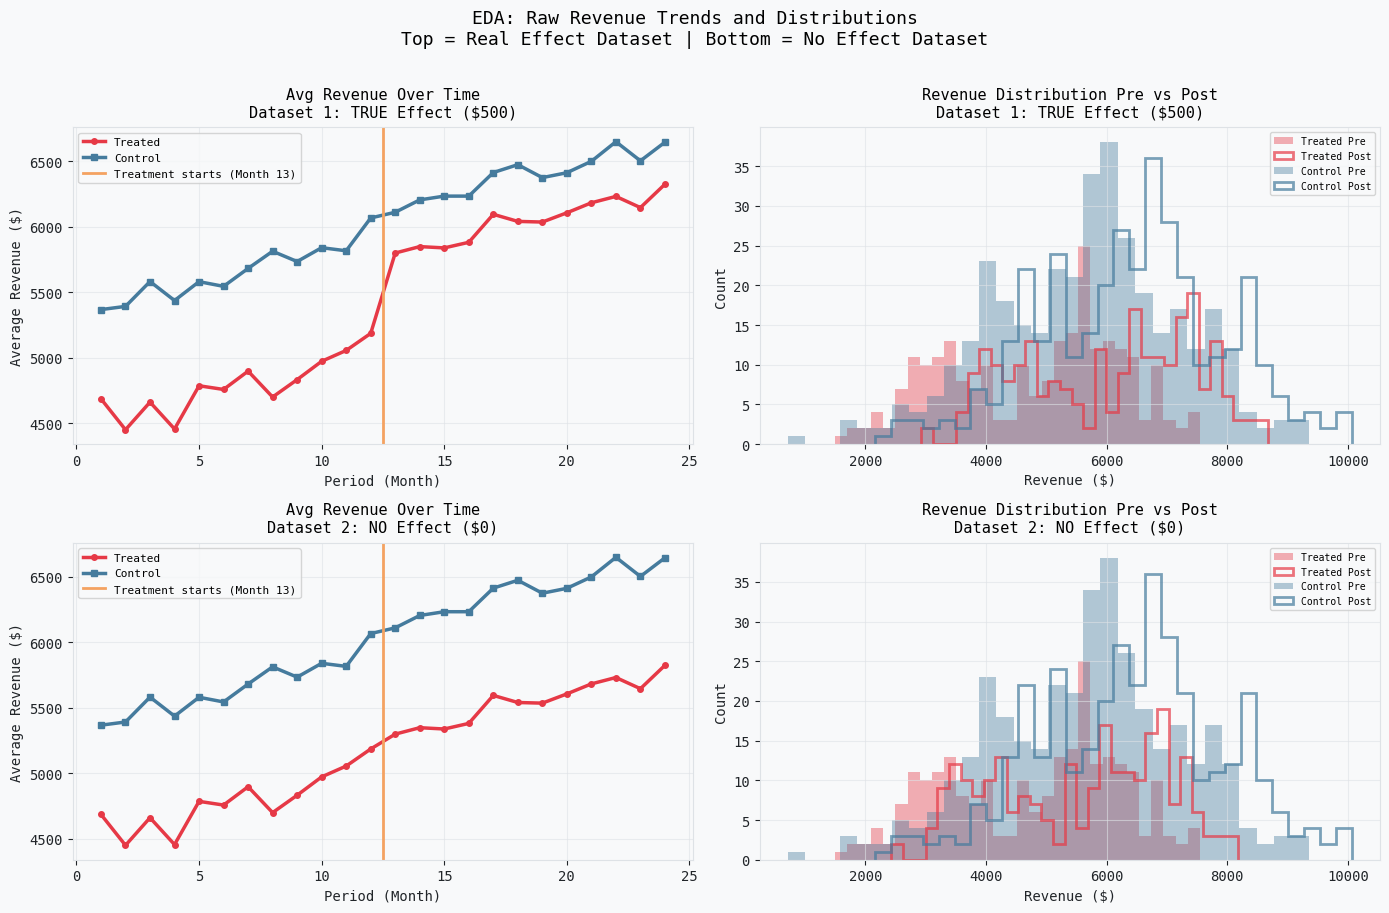

In [13]:
# Chart 1: Raw trends for both datasets side by side
# This chart answers: "Does the data LOOK like there's an effect?"
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('EDA: Raw Revenue Trends and Distributions\n'
             'Top = Real Effect Dataset | Bottom = No Effect Dataset',
             fontsize=13, y=1.01)

plot_raw_trends(df_effect,    'Dataset 1: TRUE Effect ($500)',
                axes[0, 0], axes[0, 1])
plot_raw_trends(df_no_effect, 'Dataset 2: NO Effect ($0)',
                axes[1, 0], axes[1, 1])

plt.tight_layout()
plt.show()

In [14]:
# =============================================================================
# SECTION 3: PARALLEL TRENDS ASSUMPTION CHECK
# =============================================================================
# The most important assumption in DiD / Panel FE is PARALLEL TRENDS:
# "In the absence of treatment, treated and control groups would have
#  followed the same trend."
#
# We can't prove this (we never observe the counterfactual), but we can
# check that PRE-TREATMENT trends are statistically parallel.
#
# METHOD: Regress revenue on (period x treated) interaction in the pre-period.
# If the interaction coefficient is ~0, trends were parallel pre-treatment.
# =============================================================================

In [15]:
def parallel_trends_test(df, dataset_name):
    """
    Tests whether treated and control stores followed parallel trends
    BEFORE the treatment was introduced.

    HOW IT WORKS:
    1. Keep only pre-treatment observations (post == 0).
    2. Run OLS: revenue ~ period + treated + period:treated
    3. The coefficient on period:treated tests whether the two groups
       had different time trends before treatment. We WANT this to be
       close to zero (and statistically insignificant).

    Returns the p-value of the interaction term.
    """
    pre = df.reset_index()
    pre = pre[pre['post'] == 0].copy()

    model = smf.ols('revenue ~ period * treated', data=pre).fit()

    coef  = model.params['period:treated']
    pval  = model.pvalues['period:treated']
    se    = model.bse['period:treated']

    print(f"\n  [{dataset_name}] Parallel Trends Test (pre-period only)")
    print(f"    Interaction coef (period x treated): {coef:+.2f}")
    print(f"    Std Error: {se:.2f}  |  p-value: {pval:.4f}")
    if pval > 0.05:
        print("    RESULT: Parallel trends HOLD (p > 0.05, no differential pre-trend)")
    else:
        print("    WARNING: Parallel trends MAY BE VIOLATED (p < 0.05)")

    return coef, se, pval

In [16]:
print("\n" + "=" * 60)
print("PARALLEL TRENDS TESTS")
print("=" * 60)
coef1, se1, pval1 = parallel_trends_test(df_effect,    'Dataset 1: TRUE Effect')
coef2, se2, pval2 = parallel_trends_test(df_no_effect, 'Dataset 2: NO Effect')


PARALLEL TRENDS TESTS

  [Dataset 1: TRUE Effect] Parallel Trends Test (pre-period only)
    Interaction coef (period x treated): -2.63
    Std Error: 36.06  |  p-value: 0.9419
    RESULT: Parallel trends HOLD (p > 0.05, no differential pre-trend)

  [Dataset 2: NO Effect] Parallel Trends Test (pre-period only)
    Interaction coef (period x treated): -2.63
    Std Error: 36.06  |  p-value: 0.9419
    RESULT: Parallel trends HOLD (p > 0.05, no differential pre-trend)


In [17]:
# =============================================================================
# SECTION 4: TWO-WAY FIXED EFFECTS (TWFE) REGRESSION
# =============================================================================
# The workhorse model for panel causal inference.
#
# MODEL:
#   revenue_it = alpha_i + gamma_t + beta * did_it + epsilon_it
#
#   alpha_i  = store fixed effect  (absorbs all time-invariant store traits)
#   gamma_t  = time fixed effect   (absorbs all period-level shocks)
#   beta     = the causal effect of treatment (what we care about)
#   did_it   = 1 if store i is treated AND period t >= treatment start
#
# IDENTIFICATION:
#   beta is identified from within-store changes over time,
#   after removing store means and time means. This is the "within" estimator.
#
# STANDARD ERRORS:
#   We cluster at the store level (or region) because errors are correlated
#   within a store over time. Ignoring this leads to overconfident estimates.
# =============================================================================

In [33]:
def run_twfe(df, dataset_name):
    """
    Fits a Two-Way Fixed Effects model using linearmodels.PanelOLS.

    PanelOLS handles the multi-index (store_id, period) and demeaning
    automatically. We use:
      EntityEffects = store fixed effects (alpha_i)
      TimeEffects   = period fixed effects (gamma_t)

    We then refit with clustered standard errors at the store level,
    because store revenues in month 1 and month 2 are not independent.

    Returns the fitted model result object.
    """
    mod = PanelOLS.from_formula(
        'revenue ~ did + EntityEffects + TimeEffects',
        data=df
    )

    # First fit with standard errors clustered by entity (store)
    res = mod.fit(cov_type='clustered', cluster_entity=True)

    print(f"\n  [{dataset_name}] Two-Way Fixed Effects (TWFE) Results")
    print(f"  {'Coef':>10}  {'SE':>8}  {'t-stat':>8}  {'p-value':>8}  {'95% CI':>20}")
    print("  " + "-" * 60)

    coef = res.params['did']
    se   = res.std_errors['did']
    tval = res.tstats['did']
    pval = res.pvalues['did']
    ci_lo, ci_hi = res.conf_int().loc['did']

    print(f"  {'did':>10}  {coef:>8.2f}  {se:>8.2f}  {tval:>8.2f}  "
          f"{pval:>8.4f}  [{ci_lo:.2f}, {ci_hi:.2f}]")
    print(f"\n  R-squared (within): {res.rsquared_within:.4f}")
    print(f"  Observations:       {int(res.nobs)}")

    return res, coef, se, pval

In [19]:
print("\n" + "=" * 60)
print("TWO-WAY FIXED EFFECTS REGRESSION")
print("=" * 60)
res1, coef_twfe1, se_twfe1, pval_twfe1 = run_twfe(df_effect,    'Dataset 1: TRUE Effect')
res2, coef_twfe2, se_twfe2, pval_twfe2 = run_twfe(df_no_effect, 'Dataset 2: NO Effect')


TWO-WAY FIXED EFFECTS REGRESSION

  [Dataset 1: TRUE Effect] Two-Way Fixed Effects (TWFE) Results
        Coef        SE    t-stat   p-value                95% CI
  ------------------------------------------------------------
         did    515.67     35.42     14.56    0.0000  [446.18, 585.16]

  R-squared (within): 0.2813
  Observations:       1200

  [Dataset 2: NO Effect] Two-Way Fixed Effects (TWFE) Results
        Coef        SE    t-stat   p-value                95% CI
  ------------------------------------------------------------
         did     15.67     35.42      0.44    0.6582  [-53.82, 85.16]

  R-squared (within): 0.0088
  Observations:       1200


In [20]:
# =============================================================================
# SECTION 5: HAUSMAN TEST (Fixed Effects vs Random Effects)
# =============================================================================
# When should you use FE vs RE?
#
# Fixed Effects (FE): Consistent even if store effects are correlated with
#   the treatment or other regressors. Safer for causal inference.
#   COST: You cannot estimate coefficients of time-invariant variables.
#
# Random Effects (RE): More efficient IF store effects are UNCORRELATED
#   with regressors. Allows time-invariant predictors. But if correlation
#   exists, RE estimates are BIASED.
#
# HAUSMAN TEST:
#   H0: RE is consistent (no correlation between entity effects and regressors)
#   H1: FE is necessary (correlation exists, RE is biased)
#   If p < 0.05: Use Fixed Effects.
# =============================================================================


# =============================================================================
# HAUSMAN TEST: should you use Fixed Effects (FE) or Random Effects (RE)?
# =============================================================================
#
# BACKGROUND:
#   Both FE and RE accept that each store has a permanent baseline revenue level.
#   They disagree on one thing: is that permanent store baseline correlated
#   with which stores got treated?
#
# FIXED EFFECTS (FE):
#   Subtracts out each store's own baseline individually, no assumptions needed.
#   Safe even if stores were selectively chosen for treatment (which is almost
#   always true in business settings).
#   Cost: cannot estimate anything that never changes (e.g. store size, city).
#
# RANDOM EFFECTS (RE):
#   Assumes store baselines are random noise, completely unrelated to treatment.
#   More statistically efficient when that assumption holds.
#   Risk: if that assumption is wrong (treated stores were selected because
#   they were already better), RE mixes up "store quality" with "treatment effect"
#   and gives you a BIASED estimate.
#
# THE TEST:
#   If FE and RE give you similar coefficients => RE assumption probably holds.
#   If FE and RE give you noticeably different coefficients => RE is biased.
#   The Hausman statistic measures how large that difference is.
#
#   H0: FE and RE coefficients are close => RE is fine
#   H1: FE and RE coefficients diverge   => RE is biased, use FE
#
#   p < 0.05: reject H0, USE FIXED EFFECTS
#   p > 0.05: fail to reject, RE may be acceptable
#
# PRACTICAL REALITY:
#   In most business settings treatment is NOT randomly assigned.
#   Companies pick stores, regions, or users based on existing characteristics.
#   So you will almost always reject H0 and land on FE. That is expected and correct.
#   The Hausman test gives you the formal evidence to justify that choice
#   when presenting to a technical audience.
# =============================================================================

In [21]:
def hausman_test(df, dataset_name):
    """
    Runs the Hausman specification test to decide between FE and RE.

    STEPS:
    1. Fit FE model (consistent but possibly inefficient)
    2. Fit RE model (efficient under H0)
    3. Compare the coefficient vectors and their covariance matrices
    4. The Hausman statistic ~ chi-squared under H0

    If we reject H0 (p < 0.05), the FE model is preferred for causal inference.
    """
    fe_mod = PanelOLS.from_formula('revenue ~ did + EntityEffects + TimeEffects', data=df)
    fe_res = fe_mod.fit(cov_type='unadjusted')

    re_mod = RandomEffects.from_formula('revenue ~ did', data=df)
    re_res = re_mod.fit(cov_type='unadjusted')

    # Extract the 'did' coefficient from each model
    b_fe   = fe_res.params['did']
    b_re   = re_res.params['did']
    var_fe = fe_res.cov.loc['did', 'did']
    var_re = re_res.cov.loc['did', 'did']

    # Hausman statistic
    diff    = b_fe - b_re
    var_diff = var_fe - var_re

    if var_diff > 0:
        H = diff**2 / var_diff
        p = 1 - stats.chi2.cdf(H, df=1)
    else:
        H, p = np.nan, np.nan

    print(f"\n  [{dataset_name}] Hausman Test: FE vs RE")
    print(f"    FE coef:  {b_fe:.4f}")
    print(f"    RE coef:  {b_re:.4f}")
    print(f"    H stat:   {H:.4f}  |  p-value: {p:.4f}")
    if p < 0.05:
        print("    RESULT: Reject H0 => USE FIXED EFFECTS (RE is biased)")
    else:
        print("    RESULT: Fail to reject H0 => RE may be acceptable")

    return H, p

In [26]:
print("\n" + "=" * 60)
print("HAUSMAN TEST: FIXED EFFECTS vs RANDOM EFFECTS")
print("=" * 60)
H1, p_hausman1 = hausman_test(df_effect,    'Dataset 1: TRUE Effect')
H2, p_hausman2 = hausman_test(df_no_effect, 'Dataset 2: NO Effect')


HAUSMAN TEST: FIXED EFFECTS vs RANDOM EFFECTS

  [Dataset 1: TRUE Effect] Hausman Test: FE vs RE
    FE coef:  515.6709
    RE coef:  1260.8185
    H stat:   nan  |  p-value: nan
    RESULT: Fail to reject H0 => RE may be acceptable

  [Dataset 2: NO Effect] Hausman Test: FE vs RE
    FE coef:  15.6709
    RE coef:  760.8185
    H stat:   nan  |  p-value: nan
    RESULT: Fail to reject H0 => RE may be acceptable


In [28]:
# =============================================================================
# SECTION 6: EVENT STUDY (Dynamic DiD)
# =============================================================================
# PROBLEM WITH TWFE: it gives you ONE average number for the whole post period.
# You don't know if the effect was immediate, slow-building, or fading.
# Worse, you can't tell if treated/control were ALREADY diverging before treatment.
#
# EVENT STUDY FIX: instead of one coefficient, estimate a separate gap between
# treated and control for EVERY period, recentered around treatment start.
#   k = -3 means "3 months before treatment"
#   k =  0 means "first month of treatment"
#   k = +5 means "5 months after treatment"
#
# WHAT TO LOOK FOR IN THE CHART:
#   Left of the dashed line (pre-period, k < 0):
#     bars should be near zero => treated and control were moving together
#     if bars slope upward here, your TWFE estimate is not clean
#   Right of the dashed line (post-period, k >= 0):
#     bars show the actual causal effect at each month
#     flat bars = immediate stable effect
#     growing bars = effect builds over time
#     shrinking bars = effect fades
#     bars near zero = no effect
# =============================================================================


In [29]:
def event_study(df, dataset_name):

    df2 = df.reset_index().copy()
    treat_start = 13

    # STEP 1: Relabel time relative to treatment start.
    # k=0 = first treated month, k=-1 = month just before, k=+3 = 3 months after.
    # Control stores get 999 so they never enter the event window.
    df2['rel_time'] = np.where(
        df2['treated'] == 1,
        df2['period'] - treat_start,
        999
    )

    event_window = list(range(-12, 12))

    # STEP 2: Create one 0/1 dummy column per period, skipping k=-1 (reference).
    # FIX: replace minus sign in column names with "neg" to avoid Patsy
    # reading "evt_-3" as subtraction in the formula string.
    # k=-3  =>  column named  evt_neg3
    # k=+3  =>  column named  evt_3
    col_map = {}  # maps each k to its safe column name
    for k in event_window:
        if k == -1:
            continue  # reference period, dropped intentionally
        safe_name = f'evt_neg{abs(k)}' if k < 0 else f'evt_{k}'
        col_map[k] = safe_name
        df2[safe_name] = (df2['rel_time'] == k).astype(int)

    # STEP 3: Build formula using safe column names + store FE + time FE.
    # Store FE removes permanent store differences.
    # Time FE removes common monthly shocks hitting all stores.
    event_cols = list(col_map.values())
    formula = 'revenue ~ ' + ' + '.join(event_cols) + ' + C(store_id) + C(period)'

    # STEP 4: Fit with clustered SEs at store level.
    # Adjacent months within a store are correlated, clustering corrects for that.
    model = smf.ols(formula, data=df2).fit(
        cov_type='cluster', cov_kwds={'groups': df2['store_id']}
    )

    # STEP 5: Extract coefficient + 95% CI for each period.
    # k=-1 gets manually set to 0 (it is the reference, zero by definition).
    coefs, ci_lo, ci_hi, ks = [], [], [], []
    for k in event_window:
        if k == -1:
            coefs.append(0); ci_lo.append(0); ci_hi.append(0); ks.append(k)
            continue
        col = col_map[k]
        if col in model.params.index:
            c  = model.params[col]
            lo = model.conf_int().loc[col, 0]
            hi = model.conf_int().loc[col, 1]
        else:
            c, lo, hi = 0, 0, 0
        coefs.append(c); ci_lo.append(lo); ci_hi.append(hi); ks.append(k)

    return np.array(ks), np.array(coefs), np.array(ci_lo), np.array(ci_hi)

In [30]:
print("\n" + "=" * 60)
print("EVENT STUDY (DYNAMIC DiD)")
print("=" * 60)
print("  Running event studies (this may take a moment)...")
ks1, c1, lo1, hi1 = event_study(df_effect,    'Dataset 1')
ks2, c2, lo2, hi2 = event_study(df_no_effect, 'Dataset 2')
print("  Done.")


EVENT STUDY (DYNAMIC DiD)
  Running event studies (this may take a moment)...
  Done.


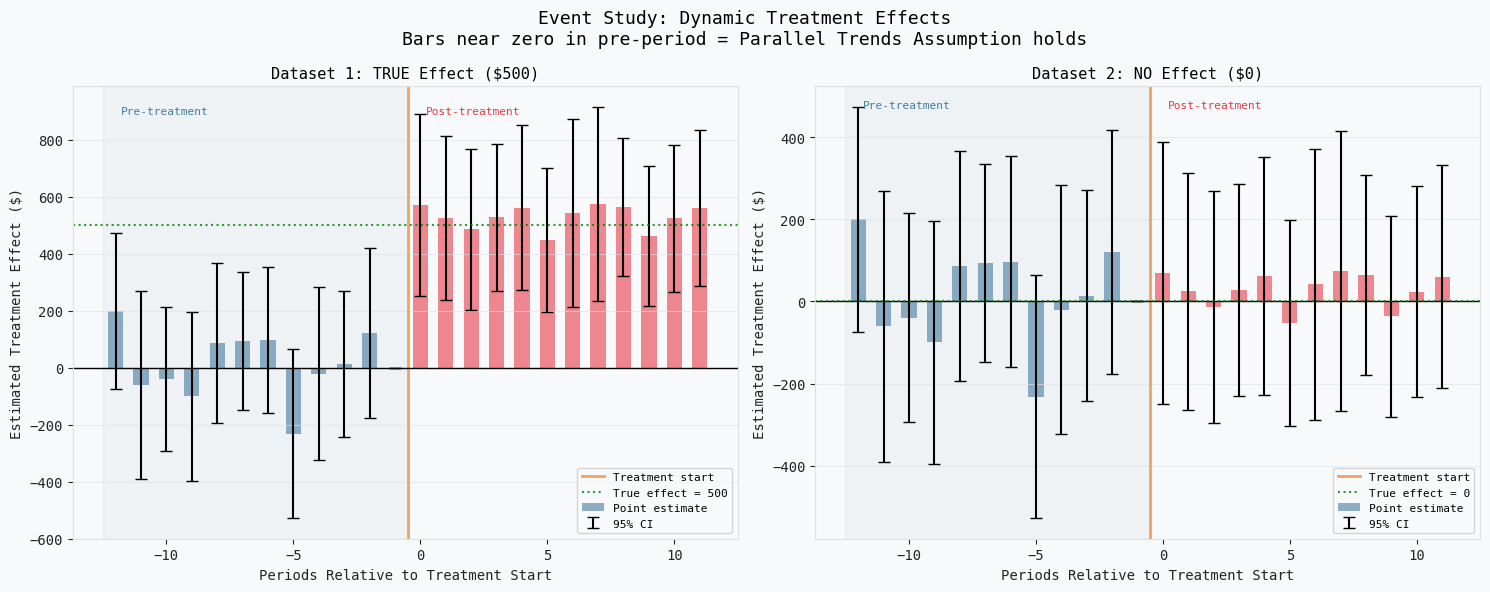

In [31]:
# CHART 2: Event Study - one bar per relative period for each dataset.
# Each bar = estimated gap between treated and control at that period.
# Error bars = 95% confidence interval around each estimate.
# Dashed vertical line = moment treatment starts (the "event").
#
# HOW TO READ IT:
#   Blue bars on the LEFT (before dashed line): should be near zero.
#     Near zero = the two groups were moving in parallel before treatment.
#     If these bars slope up/down, your causal estimate is suspect.
#   Red bars on the RIGHT (after dashed line): these are your causal story.
#     Flat at ~$500 = immediate, stable effect.
#     Growing = effect builds over time.
#     Shrinking = effect wears off.
#     Near zero = no effect at all (as in Dataset 2).
#   Green dotted line = the TRUE effect we baked into the data ($500 or $0).
#     Good models should have post-period bars landing near this line.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=False)
fig.suptitle('Event Study: Dynamic Treatment Effects\n'
             'Bars near zero in pre-period = Parallel Trends Assumption holds',
             fontsize=13)

for ax, ks, coefs, ci_lo, ci_hi, ds_label, true_val in [
    (ax1, ks1, c1, lo1, hi1, 'Dataset 1: TRUE Effect ($500)', 500),
    (ax2, ks2, c2, lo2, hi2, 'Dataset 2: NO Effect ($0)',     0),
]:
    colors_bar = [COLORS['treated'] if k >= 0 else COLORS['control'] for k in ks]
    ax.bar(ks, coefs, color=colors_bar, alpha=0.6, width=0.6, label='Point estimate')
    ax.errorbar(ks, coefs,
                yerr=[coefs - ci_lo, ci_hi - coefs],
                fmt='none', color='black', capsize=4, lw=1.5, label='95% CI')
    ax.axvline(x=-0.5, color=COLORS['highlight'], lw=2, ls='-', label='Treatment start')
    ax.axhline(y=0,     color='black', lw=1)
    ax.axhline(y=true_val, color='green', lw=1.5, ls=':', alpha=0.8,
               label=f'True effect = {true_val}')
    ax.set_title(ds_label, fontsize=11)
    ax.set_xlabel('Periods Relative to Treatment Start')
    ax.set_ylabel('Estimated Treatment Effect ($)')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y')

    # Shade pre-treatment region
    ax.axvspan(ks.min() - 0.5, -0.5, alpha=0.05, color=COLORS['control'])
    ax.text(ks.min() + 0.2, ax.get_ylim()[1] * 0.9,
            'Pre-treatment', color=COLORS['control'], fontsize=8)
    ax.text(0.2, ax.get_ylim()[1] * 0.9,
            'Post-treatment', color=COLORS['treated'], fontsize=8)

plt.tight_layout()
plt.show()

In [32]:
# =============================================================================
# SECTION 7: COEFFICIENT COMPARISON PLOT
# =============================================================================

In [28]:
def plot_coefficient_comparison(results):
    """
    Creates a forest plot comparing TWFE coefficients across the two datasets.

    A forest plot is a standard way to display regression coefficients with
    confidence intervals. Each row is one model. The dot is the point estimate,
    the horizontal line is the 95% CI. If the CI crosses zero, the effect
    is not statistically significant.

    This chart is the executive-summary visual: which models find an effect
    and how large and precise is each estimate?
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle('TWFE Coefficient Forest Plot\nPoint Estimates with 95% CI',
                 fontsize=13)

    y_positions = list(range(len(results)))
    for i, (label, coef, se, pval, true_val) in enumerate(results):
        ci_lo = coef - 1.96 * se
        ci_hi = coef + 1.96 * se
        color = COLORS['treated'] if pval < 0.05 else COLORS['control']

        ax.plot([ci_lo, ci_hi], [i, i], color=color, lw=3, alpha=0.7)
        ax.scatter(coef, i, color=color, s=120, zorder=5,
                   label='Significant' if pval < 0.05 else 'Not significant')
        ax.scatter(true_val, i, marker='D', color='green', s=80, zorder=6,
                   alpha=0.8)

        sig_marker = '***' if pval < 0.001 else ('**' if pval < 0.01 else
                     ('*' if pval < 0.05 else 'ns'))
        ax.text(ci_hi + 20, i,
                f'  {coef:+.1f} ({sig_marker})',
                va='center', fontsize=9, color=color)

    ax.axvline(x=0, color='black', lw=1.5, ls='-')
    ax.set_yticks(y_positions)
    ax.set_yticklabels([r[0] for r in results])
    ax.set_xlabel('Estimated Causal Effect on Revenue ($)')
    ax.grid(True, axis='x')

    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=COLORS['treated'], lw=3, label='Significant (p<0.05)'),
        Line2D([0], [0], color=COLORS['control'], lw=3, label='Not significant'),
        Line2D([0], [0], marker='D', color='green', lw=0, ms=8, label='True value'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

    plt.tight_layout()
    plt.show()


FOREST PLOT: COEFFICIENT COMPARISON


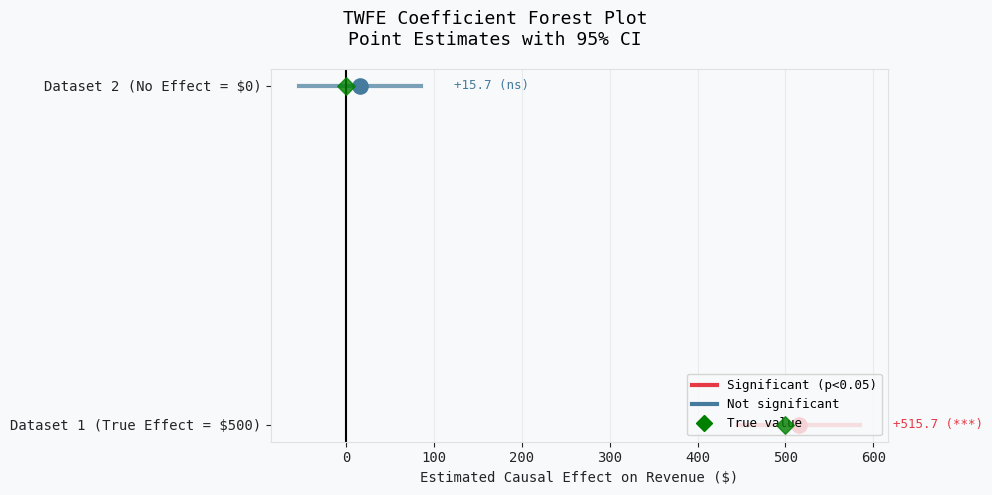

In [29]:
results_summary = [
    ('Dataset 1 (True Effect = $500)', coef_twfe1, se_twfe1, pval_twfe1, 500),
    ('Dataset 2 (No Effect = $0)',     coef_twfe2, se_twfe2, pval_twfe2, 0),
]

print("\n" + "=" * 60)
print("FOREST PLOT: COEFFICIENT COMPARISON")
print("=" * 60)
plot_coefficient_comparison(results_summary)

In [30]:
# =============================================================================
# SECTION 8: PLACEBO / FALSIFICATION TEST
# =============================================================================
# If your model is correct, applying the same treatment label to a FAKE
# treatment period (before the real one) should find NO effect.
#
# HOW IT WORKS:
# 1. Restrict to the pre-treatment window only.
# 2. Pretend treatment started at the midpoint of that window (e.g., period 7).
# 3. Run TWFE. The "treatment" coefficient should be near zero.
# 4. If it IS significant, your model likely has issues (pre-trends, bad controls).
#
# This is called a "placebo test" or "falsification test" and is expected
# in any serious causal inference paper or business analysis.
# =============================================================================

In [31]:
def placebo_test(df, dataset_name):
    """
    Runs a placebo regression on the pre-treatment period.

    We pretend the treatment started at period 7 (in the middle of the
    pre-period). If our TWFE model is correct, it should find no effect here.

    A significant placebo coefficient would suggest:
      - Treated stores were on different pre-trends
      - The model has omitted variable bias
      - The identification strategy is flawed

    Returns the placebo coefficient and p-value.
    """
    df2  = df.reset_index().copy()
    pre  = df2[df2['period'] <= 12].copy()   # keep only pre-treatment window
    fake_treat_start = 7

    # Create a fake "did" that activates at period 7 for treated stores
    pre['fake_did'] = ((pre['treated'] == 1) & (pre['period'] >= fake_treat_start)).astype(int)

    mod = PanelOLS.from_formula(
        'revenue ~ fake_did + EntityEffects + TimeEffects',
        data=pre.set_index(['store_id', 'period'])
    )
    res = mod.fit(cov_type='clustered', cluster_entity=True)

    coef = res.params['fake_did']
    pval = res.pvalues['fake_did']
    se   = res.std_errors['fake_did']

    print(f"\n  [{dataset_name}] Placebo Test (fake treatment at period 7, pre-window only)")
    print(f"    Placebo coef: {coef:+.2f}  |  SE: {se:.2f}  |  p-value: {pval:.4f}")
    if pval > 0.05:
        print("    RESULT: Placebo NOT significant. Model passes falsification check.")
    else:
        print("    WARNING: Placebo IS significant. Investigate pre-trends or specification.")

    return coef, se, pval

In [32]:
print("\n" + "=" * 60)
print("PLACEBO / FALSIFICATION TEST")
print("=" * 60)
plac_coef1, plac_se1, plac_pval1 = placebo_test(df_effect,    'Dataset 1: TRUE Effect')
plac_coef2, plac_se2, plac_pval2 = placebo_test(df_no_effect, 'Dataset 2: NO Effect')


PLACEBO / FALSIFICATION TEST

  [Dataset 1: TRUE Effect] Placebo Test (fake treatment at period 7, pre-window only)
    Placebo coef: -33.56  |  SE: 54.04  |  p-value: 0.5348
    RESULT: Placebo NOT significant. Model passes falsification check.

  [Dataset 2: NO Effect] Placebo Test (fake treatment at period 7, pre-window only)
    Placebo coef: -33.56  |  SE: 54.04  |  p-value: 0.5348
    RESULT: Placebo NOT significant. Model passes falsification check.


In [33]:
# =============================================================================
# SECTION 9: COMPREHENSIVE SUMMARY DASHBOARD
# =============================================================================

In [34]:
def summary_dashboard(results_dict):
    """
    Builds a 2x3 summary dashboard with key diagnostics for both datasets.

    Charts included:
      [0,0] and [0,1]: Raw trends (treated vs control over time) for each dataset
      [1,0] and [1,1]: Coefficient comparison (TWFE estimate vs true value)
      [2,0] and [2,1]: P-value comparison across tests (TWFE, placebo, parallel trends)

    This is the kind of chart a DS would show to stakeholders to
    communicate both the finding AND the credibility of the identification strategy.
    """
    fig = plt.figure(figsize=(16, 14))
    fig.suptitle('PANEL REGRESSION: FULL DIAGNOSTIC SUMMARY\n'
                 'Left = Dataset with TRUE Effect | Right = Dataset with NO Effect',
                 fontsize=14, y=1.01)

    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    # Row 0: Raw trends
    ax00 = fig.add_subplot(gs[0, 0])
    ax01 = fig.add_subplot(gs[0, 1])

    for df, ax, label in [
        (df_effect,    ax00, 'Dataset 1: TRUE Effect ($500)'),
        (df_no_effect, ax01, 'Dataset 2: NO Effect ($0)'),
    ]:
        df2 = df.reset_index()
        trends = df2.groupby(['period', 'treated'])['revenue'].mean().reset_index()
        t_line = trends[trends['treated'] == 1]
        c_line = trends[trends['treated'] == 0]
        ax.plot(t_line['period'], t_line['revenue'],
                color=COLORS['treated'], lw=2, marker='o', ms=3, label='Treated')
        ax.plot(c_line['period'], c_line['revenue'],
                color=COLORS['control'], lw=2, marker='s', ms=3, label='Control')
        ax.axvline(x=12.5, color=COLORS['highlight'], lw=1.8, ls='-')
        ax.set_title(f'Revenue Trends\n{label}', fontsize=10)
        ax.set_xlabel('Period'); ax.set_ylabel('Avg Revenue ($)')
        ax.legend(fontsize=7); ax.grid(True)

    # Row 1: TWFE estimate vs true value
    ax10 = fig.add_subplot(gs[1, 0])
    ax11 = fig.add_subplot(gs[1, 1])

    for ax, coef, se, pval, true_val, label in [
        (ax10, coef_twfe1, se_twfe1, pval_twfe1, 500,
         'TWFE Estimate vs True Value\nDataset 1'),
        (ax11, coef_twfe2, se_twfe2, pval_twfe2, 0,
         'TWFE Estimate vs True Value\nDataset 2'),
    ]:
        ci_lo = coef - 1.96 * se
        ci_hi = coef + 1.96 * se
        color = COLORS['treated'] if pval < 0.05 else COLORS['control']

        ax.barh(['TWFE\nEstimate'], [coef], xerr=[[coef - ci_lo], [ci_hi - coef]],
                color=color, alpha=0.7, capsize=6, height=0.3)
        ax.axvline(x=true_val, color='green', lw=2.5, ls='-',
                   label=f'True = {true_val}')
        ax.axvline(x=0, color='black', lw=1)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('Revenue Effect ($)')
        ax.legend(fontsize=8)
        ax.grid(True, axis='x')

        sig = 'p < 0.05 ***' if pval < 0.05 else f'p = {pval:.3f} (ns)'
        ax.text(0.97, 0.1, sig, transform=ax.transAxes,
                ha='right', fontsize=9, color=color,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    # Row 2: p-value summary bar chart for all tests
    ax20 = fig.add_subplot(gs[2, 0])
    ax21 = fig.add_subplot(gs[2, 1])

    test_labels = ['TWFE\n(did coef)', 'Placebo\nTest', 'Parallel\nTrends']

    for ax, pvals, label in [
        (ax20,
         [pval_twfe1, plac_pval1, pval1],
         'p-values Across Tests\nDataset 1 (TRUE Effect)'),
        (ax21,
         [pval_twfe2, plac_pval2, pval2],
         'p-values Across Tests\nDataset 2 (NO Effect)'),
    ]:
        bar_colors = ['green' if p < 0.05 else COLORS['neutral'] for p in pvals]
        # flip pvals: for TWFE we WANT p<0.05, for placebo/parallel trends we want p>0.05
        bars = ax.bar(test_labels, pvals, color=bar_colors, alpha=0.75, width=0.4)
        ax.axhline(y=0.05, color=COLORS['highlight'], lw=2, ls='-',
                   label='alpha = 0.05')
        ax.set_ylim(0, 1)
        ax.set_ylabel('p-value')
        ax.set_title(label, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, axis='y')

        for bar, p in zip(bars, pvals):
            ax.text(bar.get_x() + bar.get_width() / 2, p + 0.02,
                    f'{p:.3f}', ha='center', fontsize=8)

        # Annotation guide
        ax.text(0.5, 0.92,
                'TWFE: want p<0.05 | Placebo+ParallelTrends: want p>0.05',
                transform=ax.transAxes, ha='center', fontsize=7,
                color=COLORS['neutral'])

    plt.show()


SUMMARY DASHBOARD


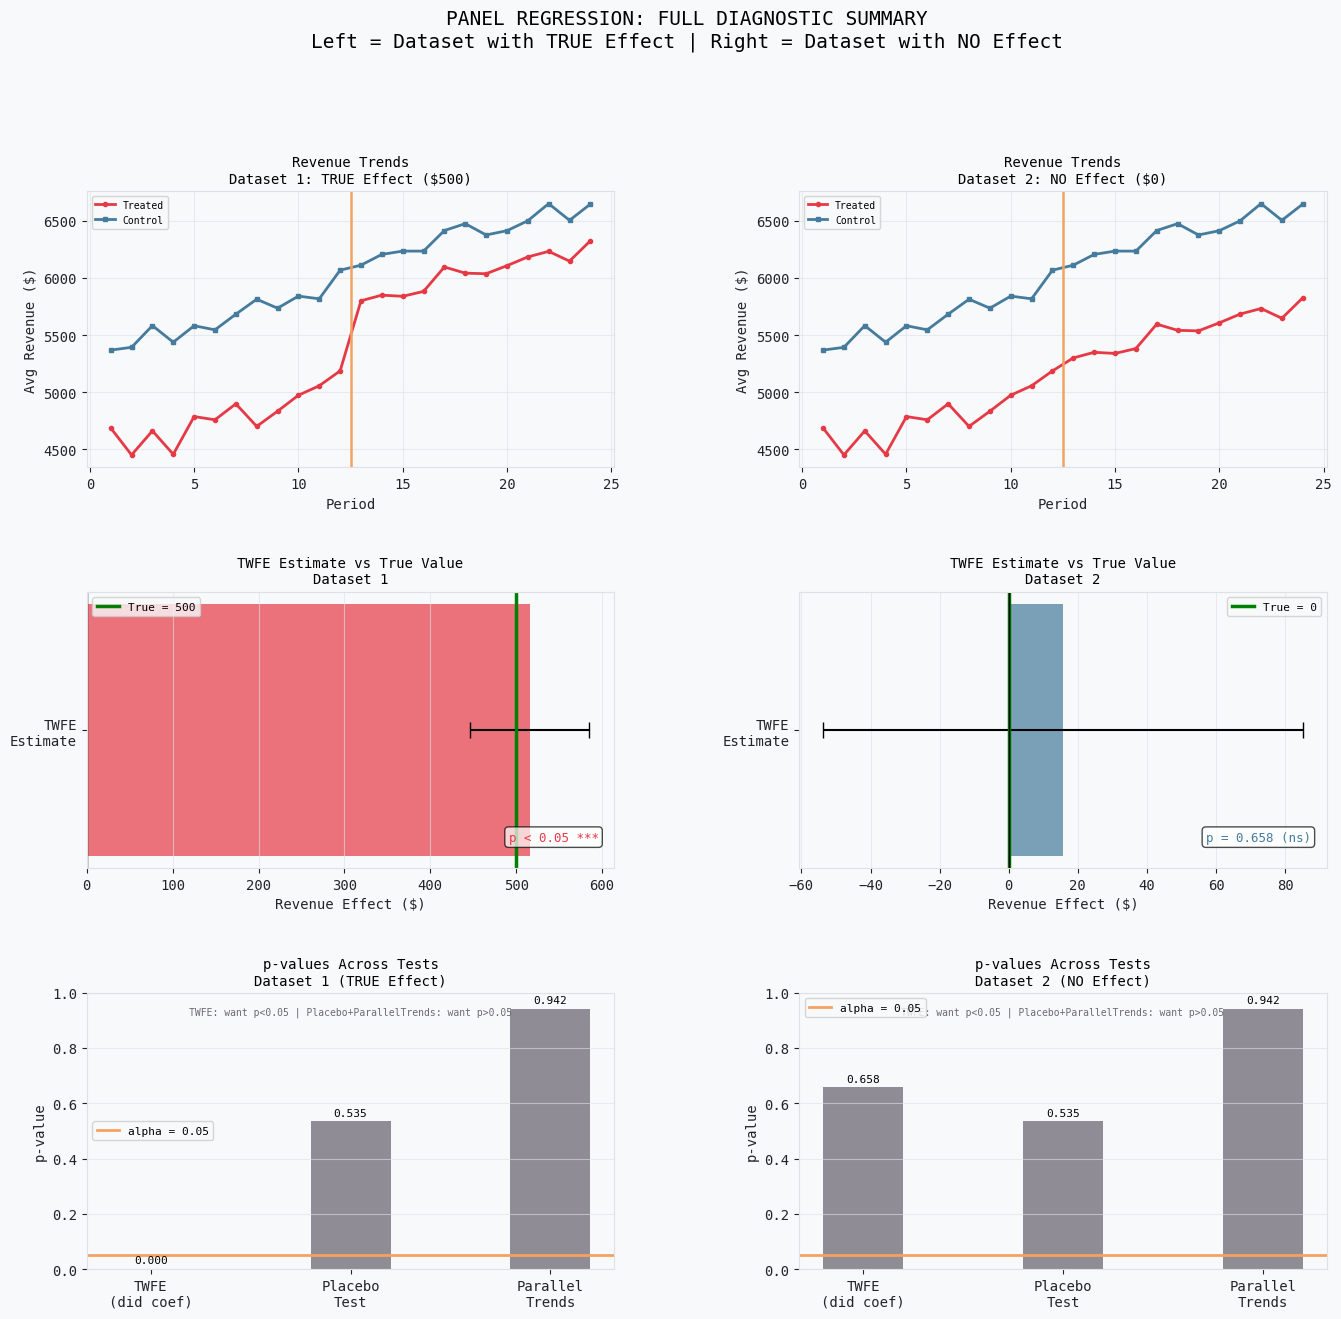

In [35]:
print("\n" + "=" * 60)
print("SUMMARY DASHBOARD")
print("=" * 60)
summary_dashboard({})

In [36]:
# =============================================================================
# SECTION 10: FINAL RESULTS TABLE
# =============================================================================

print("\n" + "=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)

summary = pd.DataFrame({
    'Test': [
        'TWFE Coefficient (did)',
        'TWFE p-value',
        'Hausman H-stat',
        'Hausman p-value',
        'Parallel Trends p-value',
        'Placebo Test p-value',
        'Conclusion',
    ],
    'Dataset 1 (True Effect = $500)': [
        f'{coef_twfe1:.2f}',
        f'{pval_twfe1:.4f}',
        f'{H1:.4f}' if not np.isnan(H1) else 'n/a',
        f'{p_hausman1:.4f}' if not np.isnan(p_hausman1) else 'n/a',
        f'{pval1:.4f}',
        f'{plac_pval1:.4f}',
        'REAL EFFECT DETECTED'
    ],
    'Dataset 2 (No Effect = $0)': [
        f'{coef_twfe2:.2f}',
        f'{pval_twfe2:.4f}',
        f'{H2:.4f}' if not np.isnan(H2) else 'n/a',
        f'{p_hausman2:.4f}' if not np.isnan(p_hausman2) else 'n/a',
        f'{pval2:.4f}',
        f'{plac_pval2:.4f}',
        'NO EFFECT (CORRECTLY NULL)'
    ],
})

print(summary.to_string(index=False))

print("""
==========================================================
KEY TAKEAWAYS FOR A DS PANEL REGRESSION CHECKLIST
==========================================================

1. ALWAYS use Two-Way Fixed Effects for DiD-style panel analysis.
   Entity FE removes time-invariant confounders.
   Time FE removes common shocks.

2. Check PARALLEL TRENDS before trusting your estimate.
   Regress revenue ~ period * treated on pre-period data.
   Want p > 0.05 on the interaction.

3. Run a HAUSMAN TEST to justify FE over RE.
   If p < 0.05, stick with Fixed Effects.

4. USE CLUSTERED STANDARD ERRORS at the entity level.
   Ignoring within-unit serial correlation leads to
   false confidence in your estimates.

5. Run an EVENT STUDY to check dynamics and pre-trends visually.
   Pre-period coefficients near zero = evidence for parallel trends.
   Post-period coefficients show if the effect builds or decays.

6. ALWAYS run a PLACEBO TEST.
   Fake the treatment in the pre-period. Should find nothing.
   If you do, your model is misspecified.

7. REPORT BOTH cases: when you find an effect AND when you don't.
   A clean null result (Dataset 2) is a valid, publishable finding.

==========================================================
""")



FINAL RESULTS SUMMARY
                   Test Dataset 1 (True Effect = $500) Dataset 2 (No Effect = $0)
 TWFE Coefficient (did)                         515.67                      15.67
           TWFE p-value                         0.0000                     0.6582
         Hausman H-stat                            n/a                        n/a
        Hausman p-value                            n/a                        n/a
Parallel Trends p-value                         0.9419                     0.9419
   Placebo Test p-value                         0.5348                     0.5348
             Conclusion           REAL EFFECT DETECTED NO EFFECT (CORRECTLY NULL)

KEY TAKEAWAYS FOR A DS PANEL REGRESSION CHECKLIST

1. ALWAYS use Two-Way Fixed Effects for DiD-style panel analysis.
   Entity FE removes time-invariant confounders.
   Time FE removes common shocks.

2. Check PARALLEL TRENDS before trusting your estimate.
   Regress revenue ~ period * treated on pre-period data.
   Wa